<a href="https://colab.research.google.com/github/Samita08/rightmove-investment-analysis/blob/main/Rightmove_Investment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


HISTORICAL GROWTH
-----------------------------
Revenue CAGR: 8.67 %
Agency ARPA CAGR: 7.28 %
Agency Branch CAGR: 0.42 %


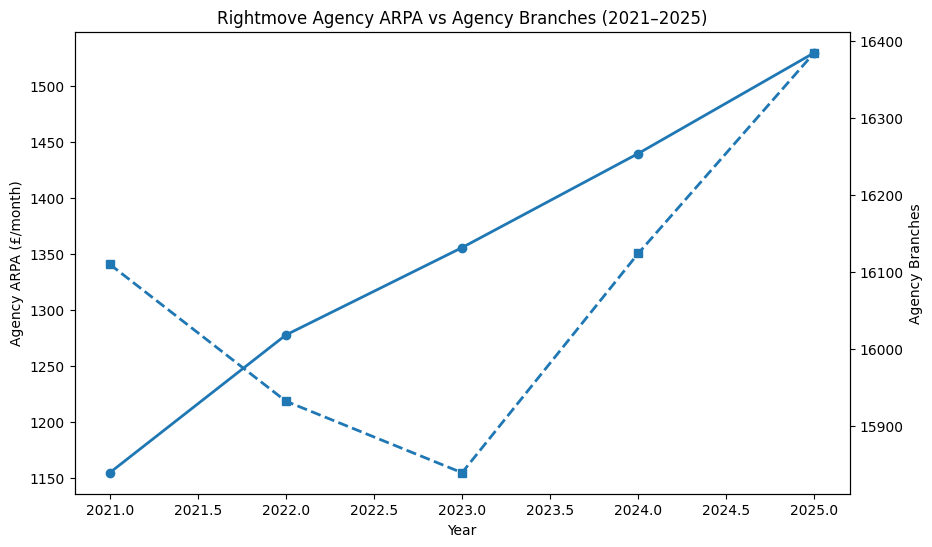


BASE-CASE FORECAST
-----------------------------
      Revenue (£m)  Revenue Growth (%)  Operating Margin (%)  \
2026        457.01                 7.5                  67.0   
2027        491.29                 7.5                  67.0   
2028        528.14                 7.5                  67.5   
2029        559.82                 6.0                  68.0   
2030        593.41                 6.0                  68.0   

      Operating Profit (£m)  UFCF (£m)  
2026                 306.20     227.20  
2027                 329.16     244.25  
2028                 356.49     264.54  
2029                 380.68     282.55  
2030                 403.52     299.51  

BASE-CASE DCF VALUATION
-----------------------------
PV of Forecast UFCF: £ 1041.3 m
PV of Terminal Value: £ 3798.82 m
Enterprise Value: £ 4840.12 m
Equity Value: £ 4883.02 m
Implied Share Price: £ 6.4

DCF SENSITIVITY TABLE
-----------------------------
      7.0%  7.5%  8.0%  8.5%  9.0%
1.5%  6.63  6.07   5.6  5.1

In [2]:
# ============================================================
# RIGHTMOVE INVESTMENT ANALYSIS AND VALUATION
# Historical Analysis | Forecast | DCF | Scenarios | Reverse DCF
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq


# ============================================================
# 1. LOAD AND CLEAN HISTORICAL DATA
# ============================================================

df = pd.read_excel("rightmove_historical_data.xlsx")

data = df.set_index("Metric").T
data = data.apply(pd.to_numeric, errors="coerce")


# ============================================================
# 2. HISTORICAL FINANCIAL ANALYSIS
# ============================================================

data["Revenue Growth (%)"] = (
    data["Revenue (£m)"].pct_change() * 100
)

data["Operating Margin (%)"] = (
    data["Operating Profit (£m)"] /
    data["Revenue (£m)"] * 100
)

data["CapEx (£m)"] = (
    data["PP&E Purchases (£m)"] +
    data["Intangible Purchases (£m)"]
)

data["Free Cash Flow (£m)"] = (
    data["Operating Cash Flow (£m)"] -
    data["CapEx (£m)"]
)

data["FCF Margin (%)"] = (
    data["Free Cash Flow (£m)"] /
    data["Revenue (£m)"] * 100
)

data["FCF Conversion (%)"] = (
    data["Free Cash Flow (£m)"] /
    data["Profit After Tax (£m)"] * 100
)


# ============================================================
# 3. OPERATING DRIVER ANALYSIS
# ============================================================

data["Agency ARPA Growth (%)"] = (
    data["Agency ARPA (£/month)"].pct_change() * 100
)

data["Agency Branch Growth (%)"] = (
    data["Agency Branches"].pct_change() * 100
)

data["Agency Revenue Growth (%)"] = (
    data["Agency Revenue (£m)"].pct_change() * 100
)

data["New Homes ARPA Growth (%)"] = (
    data["New Homes ARPA (£/month)"].pct_change() * 100
)

data["New Homes Development Growth (%)"] = (
    data["New Homes Developments"].pct_change() * 100
)

data["New Homes Revenue Growth (%)"] = (
    data["New Homes Revenue (£m)"].pct_change() * 100
)


# ============================================================
# 4. HISTORICAL CAGR
# ============================================================

years = 4

revenue_cagr = (
    (data.loc[2025, "Revenue (£m)"] /
     data.loc[2021, "Revenue (£m)"]) ** (1 / years) - 1
) * 100

agency_arpa_cagr = (
    (data.loc[2025, "Agency ARPA (£/month)"] /
     data.loc[2021, "Agency ARPA (£/month)"]) ** (1 / years) - 1
) * 100

agency_branch_cagr = (
    (data.loc[2025, "Agency Branches"] /
     data.loc[2021, "Agency Branches"]) ** (1 / years) - 1
) * 100

print("\nHISTORICAL GROWTH")
print("-----------------------------")
print("Revenue CAGR:", round(revenue_cagr, 2), "%")
print("Agency ARPA CAGR:", round(agency_arpa_cagr, 2), "%")
print("Agency Branch CAGR:", round(agency_branch_cagr, 2), "%")


# ============================================================
# 5. ARPA VS AGENCY BRANCHES CHART
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    data.index,
    data["Agency ARPA (£/month)"],
    marker="o",
    linewidth=2
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Agency ARPA (£/month)")
ax1.set_title(
    "Rightmove Agency ARPA vs Agency Branches (2021–2025)"
)

ax2 = ax1.twinx()

ax2.plot(
    data.index,
    data["Agency Branches"],
    marker="s",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel("Agency Branches")

plt.show()


# ============================================================
# 6. BASE-CASE FORECAST
# ============================================================

forecast = pd.DataFrame(
    index=[2026, 2027, 2028, 2029, 2030]
)

forecast["Revenue Growth (%)"] = [
    7.5, 7.5, 7.5, 6.0, 6.0
]

forecast["Revenue (£m)"] = 0.0

previous_revenue = data.loc[2025, "Revenue (£m)"]

for year in forecast.index:

    growth = (
        forecast.loc[year, "Revenue Growth (%)"] / 100
    )

    forecast.loc[year, "Revenue (£m)"] = (
        previous_revenue * (1 + growth)
    )

    previous_revenue = (
        forecast.loc[year, "Revenue (£m)"]
    )


# ============================================================
# 7. OPERATING PROFIT FORECAST
# ============================================================

forecast["Operating Margin (%)"] = [
    67.0,
    67.0,
    67.5,
    68.0,
    68.0
]

forecast["Operating Profit (£m)"] = (
    forecast["Revenue (£m)"] *
    forecast["Operating Margin (%)"] / 100
)


# ============================================================
# 8. NOPAT
# ============================================================

forecast["Tax Rate (%)"] = 25.0

forecast["NOPAT (£m)"] = (
    forecast["Operating Profit (£m)"] *
    (1 - forecast["Tax Rate (%)"] / 100)
)


# ============================================================
# 9. D&A AND CAPEX
# ============================================================

forecast["D&A (% Revenue)"] = 2.0

forecast["D&A (£m)"] = (
    forecast["Revenue (£m)"] * 0.02
)

forecast["CapEx (% Revenue)"] = 2.5

forecast["CapEx (£m)"] = (
    forecast["Revenue (£m)"] * 0.025
)


# ============================================================
# 10. WORKING CAPITAL
# ============================================================

forecast["Change in NWC (£m)"] = 0.0

previous_revenue = data.loc[2025, "Revenue (£m)"]

for year in forecast.index:

    revenue_change = (
        forecast.loc[year, "Revenue (£m)"]
        - previous_revenue
    )

    forecast.loc[year, "Change in NWC (£m)"] = (
        revenue_change * 0.005
    )

    previous_revenue = (
        forecast.loc[year, "Revenue (£m)"]
    )


# ============================================================
# 11. UNLEVERED FREE CASH FLOW
# ============================================================

forecast["UFCF (£m)"] = (
    forecast["NOPAT (£m)"]
    + forecast["D&A (£m)"]
    - forecast["CapEx (£m)"]
    - forecast["Change in NWC (£m)"]
)

print("\nBASE-CASE FORECAST")
print("-----------------------------")

print(
    forecast[[
        "Revenue (£m)",
        "Revenue Growth (%)",
        "Operating Margin (%)",
        "Operating Profit (£m)",
        "UFCF (£m)"
    ]].round(2)
)


# ============================================================
# 12. DCF ASSUMPTIONS
# ============================================================

wacc = 0.08
terminal_growth = 0.025

forecast["Discount Period"] = range(1, 6)

forecast["Discount Factor"] = (
    1 /
    (1 + wacc) ** forecast["Discount Period"]
)

forecast["PV of UFCF (£m)"] = (
    forecast["UFCF (£m)"] *
    forecast["Discount Factor"]
)


# ============================================================
# 13. TERMINAL VALUE
# ============================================================

terminal_value = (
    forecast.loc[2030, "UFCF (£m)"]
    * (1 + terminal_growth)
    / (wacc - terminal_growth)
)

pv_terminal_value = (
    terminal_value /
    (1 + wacc) ** 5
)

pv_forecast_cash_flows = (
    forecast["PV of UFCF (£m)"].sum()
)

enterprise_value = (
    pv_forecast_cash_flows +
    pv_terminal_value
)


# ============================================================
# 14. ENTERPRISE VALUE TO EQUITY VALUE
# ============================================================

cash = 37.223
money_market_deposits = 5.683
debt = 0

cash_like_assets = (
    cash + money_market_deposits
)

equity_value = (
    enterprise_value
    + cash_like_assets
    - debt
)


# ============================================================
# 15. IMPLIED SHARE PRICE
# ============================================================

shares_issued = 773.281827
treasury_shares = 10.753494

shares_outstanding = (
    shares_issued - treasury_shares
)

implied_share_price = (
    equity_value /
    shares_outstanding
)

print("\nBASE-CASE DCF VALUATION")
print("-----------------------------")

print(
    "PV of Forecast UFCF: £",
    round(pv_forecast_cash_flows, 2),
    "m"
)

print(
    "PV of Terminal Value: £",
    round(pv_terminal_value, 2),
    "m"
)

print(
    "Enterprise Value: £",
    round(enterprise_value, 2),
    "m"
)

print(
    "Equity Value: £",
    round(equity_value, 2),
    "m"
)

print(
    "Implied Share Price: £",
    round(implied_share_price, 2)
)


# ============================================================
# 16. DCF SENSITIVITY ANALYSIS
# ============================================================

wacc_range = [
    0.07,
    0.075,
    0.08,
    0.085,
    0.09
]

growth_range = [
    0.015,
    0.02,
    0.025,
    0.03,
    0.035
]

sensitivity = pd.DataFrame(
    index=[
        f"{g*100:.1f}%"
        for g in growth_range
    ],
    columns=[
        f"{w*100:.1f}%"
        for w in wacc_range
    ]
)

for g in growth_range:

    for w in wacc_range:

        pv_fcfs = sum(
            forecast.loc[year, "UFCF (£m)"] /
            (1 + w) ** (year - 2025)
            for year in forecast.index
        )

        tv = (
            forecast.loc[2030, "UFCF (£m)"]
            * (1 + g)
            / (w - g)
        )

        pv_tv = (
            tv /
            (1 + w) ** 5
        )

        ev = pv_fcfs + pv_tv

        eq_value = (
            ev +
            cash_like_assets -
            debt
        )

        price = (
            eq_value /
            shares_outstanding
        )

        sensitivity.loc[
            f"{g*100:.1f}%",
            f"{w*100:.1f}%"
        ] = round(price, 2)

print("\nDCF SENSITIVITY TABLE")
print("-----------------------------")
print(sensitivity)


# ============================================================
# 17. REVERSE DCF
# ============================================================

market_price = 4.99

def implied_price(revenue_growth):

    revenue = data.loc[
        2025,
        "Revenue (£m)"
    ]

    projected_revenues = []

    for year in range(2026, 2031):

        revenue = (
            revenue *
            (1 + revenue_growth)
        )

        projected_revenues.append(
            revenue
        )

    margins = [
        0.67,
        0.67,
        0.675,
        0.68,
        0.68
    ]

    ufcfs = []

    previous_revenue = data.loc[
        2025,
        "Revenue (£m)"
    ]

    for revenue, margin in zip(
        projected_revenues,
        margins
    ):

        ebit = revenue * margin

        nopat = (
            ebit * 0.75
        )

        da = (
            revenue * 0.02
        )

        capex = (
            revenue * 0.025
        )

        change_nwc = (
            revenue -
            previous_revenue
        ) * 0.005

        ufcf = (
            nopat
            + da
            - capex
            - change_nwc
        )

        ufcfs.append(ufcf)

        previous_revenue = revenue

    pv_fcfs = sum(
        fcf /
        (1 + wacc) ** year
        for year, fcf
        in enumerate(
            ufcfs,
            start=1
        )
    )

    tv = (
        ufcfs[-1]
        * (1 + terminal_growth)
        / (wacc - terminal_growth)
    )

    pv_tv = (
        tv /
        (1 + wacc) ** 5
    )

    ev = (
        pv_fcfs +
        pv_tv
    )

    equity = (
        ev +
        cash_like_assets -
        debt
    )

    return (
        equity /
        shares_outstanding
    )


implied_growth = brentq(
    lambda g:
    implied_price(g) -
    market_price,
    0.00,
    0.08
)

print("\nREVERSE DCF")
print("-----------------------------")

print(
    "Market Price: £",
    market_price
)

print(
    "Market-Implied Annual Revenue Growth:",
    round(
        implied_growth * 100,
        2
    ),
    "%"
)

print(
    "DCF Check: £",
    round(
        implied_price(
            implied_growth
        ),
        2
    )
)


# ============================================================
# 18. BEAR / BASE / BULL SCENARIOS
# ============================================================

scenarios = {

    "Bear": {

        "growth": [
            0.04,
            0.04,
            0.04,
            0.03,
            0.03
        ],

        "margin": [
            0.64,
            0.64,
            0.645,
            0.65,
            0.65
        ],

        "wacc": 0.09,

        "terminal_growth": 0.02
    },

    "Base": {

        "growth": [
            0.075,
            0.075,
            0.075,
            0.06,
            0.06
        ],

        "margin": [
            0.67,
            0.67,
            0.675,
            0.68,
            0.68
        ],

        "wacc": 0.08,

        "terminal_growth": 0.025
    },

    "Bull": {

        "growth": [
            0.10,
            0.10,
            0.10,
            0.08,
            0.08
        ],

        "margin": [
            0.69,
            0.69,
            0.70,
            0.71,
            0.71
        ],

        "wacc": 0.075,

        "terminal_growth": 0.03
    }
}


def scenario_valuation(params):

    revenue = data.loc[
        2025,
        "Revenue (£m)"
    ]

    previous_revenue = revenue

    ufcfs = []

    for growth, margin in zip(
        params["growth"],
        params["margin"]
    ):

        revenue = (
            revenue *
            (1 + growth)
        )

        ebit = (
            revenue *
            margin
        )

        nopat = (
            ebit *
            0.75
        )

        da = (
            revenue *
            0.02
        )

        capex = (
            revenue *
            0.025
        )

        change_nwc = (
            revenue -
            previous_revenue
        ) * 0.005

        ufcf = (
            nopat
            + da
            - capex
            - change_nwc
        )

        ufcfs.append(
            ufcf
        )

        previous_revenue = revenue

    w = params["wacc"]
    g = params["terminal_growth"]

    pv_fcfs = sum(
        fcf /
        (1 + w) ** period
        for period, fcf
        in enumerate(
            ufcfs,
            start=1
        )
    )

    terminal_value = (
        ufcfs[-1]
        * (1 + g)
        / (w - g)
    )

    pv_terminal = (
        terminal_value /
        (1 + w) ** 5
    )

    enterprise_value = (
        pv_fcfs +
        pv_terminal
    )

    equity_value = (
        enterprise_value
        + cash_like_assets
        - debt
    )

    return (
        equity_value /
        shares_outstanding
    )


print("\nSCENARIO VALUATION")
print("-----------------------------")

scenario_results = {}

for name, params in scenarios.items():

    price = scenario_valuation(
        params
    )

    scenario_results[name] = price

    upside = (
        price /
        market_price -
        1
    ) * 100

    print(
        f"{name}: "
        f"£{price:.2f} "
        f"({upside:+.1f}% vs market)"
    )


# ============================================================
# 19. CONSENSUS-ADJUSTED BASE CASE
# ============================================================

consensus_base = {

    "growth": [
        0.07,
        0.082,
        0.085,
        0.06,
        0.06
    ],

    "margin": [
        0.67,
        0.66,
        0.655,
        0.66,
        0.67
    ],

    "wacc": 0.08,

    "terminal_growth": 0.025
}

consensus_base_price = (
    scenario_valuation(
        consensus_base
    )
)

consensus_upside = (
    consensus_base_price /
    market_price -
    1
) * 100

print("\nCONSENSUS-ADJUSTED VALUATION")
print("-----------------------------")

print(
    "Implied Share Price: £",
    round(
        consensus_base_price,
        2
    )
)

print(
    "Upside / Downside:",
    round(
        consensus_upside,
        1
    ),
    "%"
)


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n================================")
print("RIGHTMOVE INVESTMENT SUMMARY")
print("================================")

print(
    "Historical Revenue CAGR:",
    round(revenue_cagr, 2),
    "%"
)

print(
    "Agency ARPA CAGR:",
    round(agency_arpa_cagr, 2),
    "%"
)

print(
    "Agency Branch CAGR:",
    round(agency_branch_cagr, 2),
    "%"
)

print(
    "Base DCF Value: £",
    round(
        implied_share_price,
        2
    )
)

print(
    "Consensus-Adjusted Value: £",
    round(
        consensus_base_price,
        2
    )
)

print(
    "Market Reference Price: £",
    market_price
)

print(
    "Reverse-DCF Revenue Growth:",
    round(
        implied_growth * 100,
        2
    ),
    "%"
)

print(
    "Bear Case: £",
    round(
        scenario_results["Bear"],
        2
    )
)

print(
    "Base Case: £",
    round(
        scenario_results["Base"],
        2
    )
)

print(
    "Bull Case: £",
    round(
        scenario_results["Bull"],
        2
    )
)

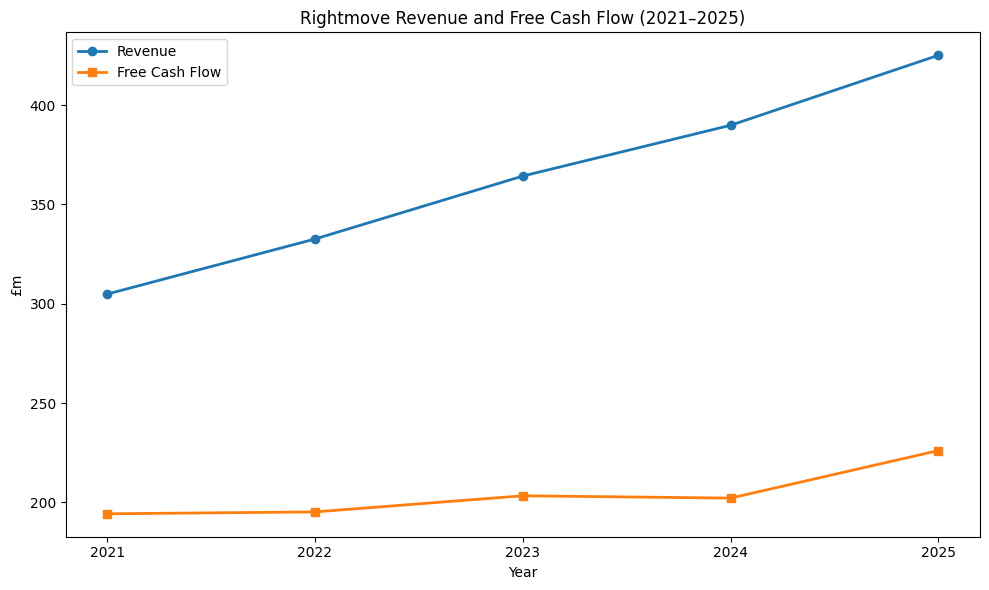

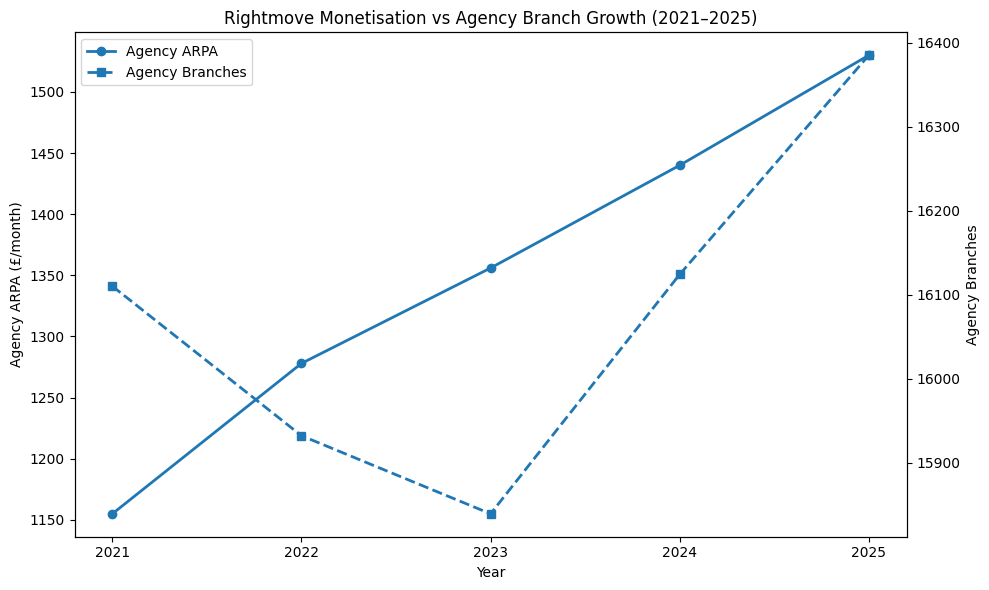

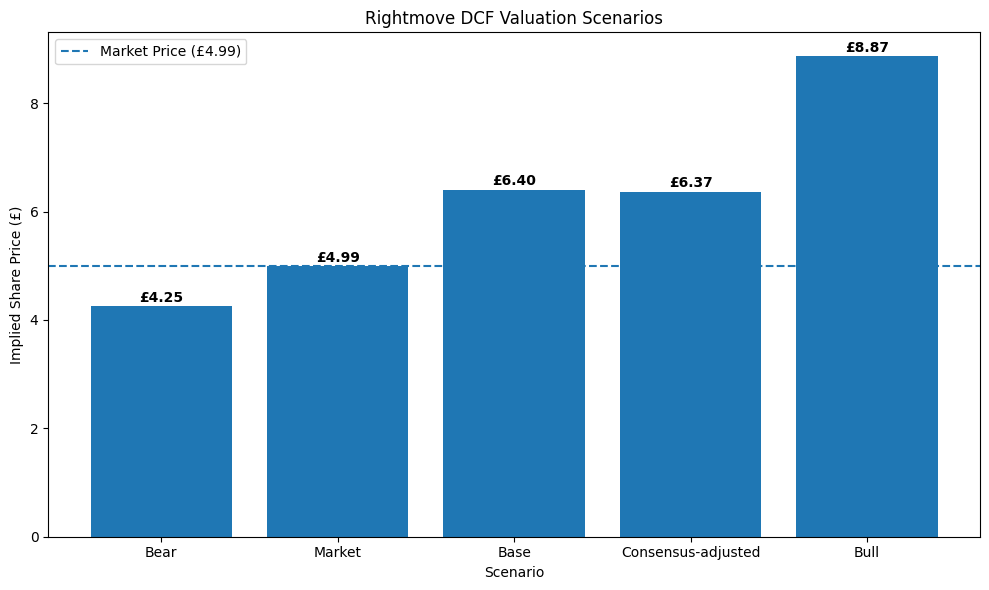

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# MAKE SURE PLOTTED DATA IS NUMERIC
# ============================================================

years = pd.to_numeric(pd.Index(data.index), errors="coerce").astype(int)

revenue = pd.to_numeric(
    data["Revenue (£m)"],
    errors="coerce"
).astype(float).to_numpy()

fcf = pd.to_numeric(
    data["Free Cash Flow (£m)"],
    errors="coerce"
).astype(float).to_numpy()

agency_arpa = pd.to_numeric(
    data["Agency ARPA (£/month)"],
    errors="coerce"
).astype(float).to_numpy()

agency_branches = pd.to_numeric(
    data["Agency Branches"],
    errors="coerce"
).astype(float).to_numpy()


# ============================================================
# CHART 1: REVENUE AND FREE CASH FLOW
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    years,
    revenue,
    marker="o",
    linewidth=2,
    label="Revenue"
)

ax.plot(
    years,
    fcf,
    marker="s",
    linewidth=2,
    label="Free Cash Flow"
)

ax.set_title("Rightmove Revenue and Free Cash Flow (2021–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("£m")
ax.set_xticks(years)
ax.legend()

plt.tight_layout()
plt.savefig("revenue_fcf.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# CHART 2: AGENCY ARPA VS AGENCY BRANCHES
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(
    years,
    agency_arpa,
    marker="o",
    linewidth=2,
    label="Agency ARPA"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Agency ARPA (£/month)")
ax1.set_title(
    "Rightmove Monetisation vs Agency Branch Growth (2021–2025)"
)
ax1.set_xticks(years)

ax2 = ax1.twinx()

line2 = ax2.plot(
    years,
    agency_branches,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Agency Branches"
)

ax2.set_ylabel("Agency Branches")

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left"
)

plt.tight_layout()
plt.savefig("arpa_branches.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# CHART 3: DCF VALUATION SCENARIOS
# ============================================================

labels = [
    "Bear",
    "Market",
    "Base",
    "Consensus-adjusted",
    "Bull"
]

values = np.array([
    float(scenario_results["Bear"]),
    float(market_price),
    float(scenario_results["Base"]),
    float(consensus_base_price),
    float(scenario_results["Bull"])
])

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    values
)

ax.axhline(
    float(market_price),
    linestyle="--",
    linewidth=1.5,
    label=f"Market Price (£{float(market_price):.2f})"
)

ax.set_title("Rightmove DCF Valuation Scenarios")
ax.set_ylabel("Implied Share Price (£)")
ax.set_xlabel("Scenario")
ax.legend()

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"£{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("valuation.png", dpi=300, bbox_inches="tight")
plt.show()